<a href="https://colab.research.google.com/github/nguyenngoctanthanh/THDeeplearningBuoi4/blob/main/Buoi_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. DOC DU LIEU
df = pd.read_csv("/content/sample_data/dulieuxettuyendaihoc.csv")

print("===== 5 DONG DAU =====")
print(df.head())

print("\n===== THONG TIN DATA =====")
print(df.info())

print("\n===== DU LIEU THIEU =====")
print(df.isnull().sum())

# 2. CHON X VA y
X = df.drop("DH1", axis=1)
y = df["DH1"]

# 3. TACH NUMERIC VA CATEGORICAL

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("\n===== NUMERIC COLS =====")
print(numeric_cols)

print("\n===== CATEGORICAL COLS =====")
print(categorical_cols)

# 4. SPLIT TRAIN / TEST
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\n===== KICH THUOC =====")
print("Train:", X_train.shape)
print("Test :", X_test.shape)

# 5. XU LY MISSING VALUE CHO NUMERIC
imputer_num = SimpleImputer(strategy="mean")

X_train_num_filled = imputer_num.fit_transform(X_train[numeric_cols])
X_test_num_filled = imputer_num.transform(X_test[numeric_cols])

# 6. STANDARD SCALING
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_num_filled)
X_test_num = scaler.transform(X_test_num_filled)

print("\n===== STANDARD SCALING =====")
print("Da xu ly NaN va scale numeric")

# 7. XU LY MISSING VALUE CHO CATEGORICAL
imputer_cat = SimpleImputer(strategy="most_frequent")

X_train_cat_filled = imputer_cat.fit_transform(X_train[categorical_cols])
X_test_cat_filled = imputer_cat.transform(X_test[categorical_cols])

# 8. ONE HOT ENCODING
encoder = OneHotEncoder(handle_unknown="ignore")

X_train_cat = encoder.fit_transform(X_train_cat_filled)
X_test_cat = encoder.transform(X_test_cat_filled)

print("\n===== ONE HOT ENCODING =====")
print("Da xu ly NaN va encode categorical")
# 9. GHEP DU LIEU
X_train_final = np.hstack([
    X_train_num,
    X_train_cat.toarray()
])

X_test_final = np.hstack([
    X_test_num,
    X_test_cat.toarray()
])

print("\n===== DU LIEU CUOI =====")
print("Train:", X_train_final.shape)
print("Test :", X_test_final.shape)

# 10. TRAIN MODEL
model = LinearRegression()
model.fit(X_train_final, y_train)

print("\n===== TRAIN MODEL =====")
print("Da train xong")
# 11. DU DOAN
y_pred = model.predict(X_test_final)

print("\n===== 5 GIA TRI DU DOAN =====")
print(y_pred[:5])

# 12. DANH GIA MO HINH
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===== DANH GIA =====")
print("MSE =", mse)
print("MAE =", mae)
print("R2  =", r2)

# 13. KIEM TRA CON NAN KHONG
print("\n===== KIEM TRA NAN =====")
print("NaN trong X_train_final:", np.isnan(X_train_final).sum())
print("NaN trong X_test_final :", np.isnan(X_test_final).sum())

# 14. ANN
print("\n===== ANN =====")
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_final.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_ann = ann_model.fit(
    X_train_final, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

y_pred_ann = ann_model.predict(X_test_final).flatten()
mse_ann = mean_squared_error(y_test, y_pred_ann)
mae_ann = mean_absolute_error(y_test, y_pred_ann)
r2_ann = r2_score(y_test, y_pred_ann)
print(f"ANN -> MSE: {mse_ann:.4f}, MAE: {mae_ann:.4f}, R2: {r2_ann:.4f}")

# 15. CNN 1D
print("\n===== CNN 1D =====")
X_train_cnn = X_train_final.reshape(X_train_final.shape[0], X_train_final.shape[1], 1)
X_test_cnn = X_test_final.reshape(X_test_final.shape[0], X_test_final.shape[1], 1)

cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train_final.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='linear')
])
cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

y_pred_cnn = cnn_model.predict(X_test_cnn).flatten()
mse_cnn = mean_squared_error(y_test, y_pred_cnn)
mae_cnn = mean_absolute_error(y_test, y_pred_cnn)
r2_cnn = r2_score(y_test, y_pred_cnn)
print(f"CNN -> MSE: {mse_cnn:.4f}, MAE: {mae_cnn:.4f}, R2: {r2_cnn:.4f}")

# So sánh cả ba
print("\n===== SO SÁNH =====")
print(f"Linear Regression: R2 = {r2_lr:.4f}" if 'r2_lr' in dir() else "Linear chưa có biến")
print(f"ANN              : R2 = {r2_ann:.4f}")
print(f"CNN              : R2 = {r2_cnn:.4f}")



===== 5 DONG DAU =====
   STT   T1   L1   H1   S1   V1   X1   D1   N1   T2  ...   X6   D6   N6  GT  \
0    1  7.2  7.3  6.3  7.3  7.0  7.9  7.3  5.5  8.4  ...  6.6  7.6  5.9   F   
1    2  5.4  3.9  3.9  4.0  5.4  5.4  5.3  2.8  6.3  ...  6.6  6.1  4.4   M   
2    3  5.6  6.8  7.2  7.5  4.3  7.4  5.8  3.2  5.0  ...  7.9  8.1  4.6   M   
3    4  6.6  6.4  5.3  6.9  5.4  7.3  6.4  5.8  5.1  ...  7.1  7.3  7.4   M   
4    5  6.0  5.0  6.0  7.3  6.5  7.7  7.9  6.1  5.4  ...  6.1  7.5  7.2   M   

   DT   KV   DH1   DH2   DH3  KT  
0 NaN  2NT  3.25  3.25  4.50  A1  
1 NaN    1  6.00  4.00  3.50   C  
2 NaN    1  5.00  6.75  4.00   C  
3 NaN    1  4.25  4.25  5.25  D1  
4 NaN  2NT  4.25  4.50  5.00   A  

[5 rows x 56 columns]

===== THONG TIN DATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 56 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   STT     100 non-null    int64  
 1   T1      100 non-null 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 18.8913 - mae: 4.0676 - val_loss: 13.2218 - val_mae: 3.3485
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 13.5905 - mae: 3.3982 - val_loss: 9.8579 - val_mae: 2.8090
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.0830 - mae: 2.6621 - val_loss: 7.2575 - val_mae: 2.2906
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 6.5830 - mae: 2.1619 - val_loss: 5.0098 - val_mae: 1.7342
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 4.6141 - mae: 1.8097 - val_loss: 3.4338 - val_mae: 1.4256
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3.0076 - mae: 1.4358 - val_loss: 2.8646 - val_mae: 1.3097
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3.3835 - mae: 1.3031 - val_loss: 2.7336 - val_mae: 1.2948
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 3.2790 - mae: 1.3671 - val_loss: 2.5427 - val_mae: 1.2350
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3.2808 - mae: 1.4114 - 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 11.6553 - mae: 3.0442 - val_loss: 3.7651 - val_mae: 1.4923
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 4.2410 - mae: 1.6718 - val_loss: 2.6136 - val_mae: 1.4144
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 6.2706 - mae: 1.9988 - val_loss: 1.7951 - val_mae: 0.9678
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.6640 - mae: 1.4640 - val_loss: 2.8089 - val_mae: 1.2753
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 3.1479 - mae: 1.4753 - val_loss: 2.1668 - val_mae: 1.1022
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3.2353 - mae: 1.3983 - val_loss: 1.8581 - val_mae: 1.0560
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 3.0611 - mae: 1.3775 - val_loss: 1.9588 - val_mae: 1.0672
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 2.8795 - mae: 1.3710 - val_loss: 2.0184 - val_mae: 1.0884
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 2.4286 - mae: 1.2879 - va

# Mục mới

In [ ]:


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Reshape
from tensorflow.keras.callbacks import EarlyStopping

# 1. DOC DU LIEU

df = pd.read_csv("/content/sample_data/titanic_disaster.csv")

print("===== 5 DONG DAU =====")
print(df.head())
# 2. XEM THONG TIN

print("\n===== THONG TIN DATA =====")
print(df.info())

# 3. KIEM TRA GIA TRI THIEU

print("\n===== GIA TRI THIEU =====")
print(df.isnull().sum())

# 4. CHON X VA y

# y = cot can du doan
y = df["Survived"]

# X = du lieu dau vao
X = df.drop("Survived", axis=1)

# 5. XOA CAC COT KHONG CAN THIET

drop_cols = ["Name", "Ticket", "Cabin"]

X = X.drop(columns=drop_cols)

# 6. TACH NUMERIC / CATEGORICAL

numeric_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = X.select_dtypes(
    include=["object"]
).columns

print("\n===== NUMERIC =====")
print(numeric_cols)

print("\n===== CATEGORICAL =====")
print(categorical_cols)


# 7. SPLIT TRAIN / TEST

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# 8. XU LY NaN CHO NUMERIC

imputer_num = SimpleImputer(
    strategy="mean"
)

X_train_num = imputer_num.fit_transform(
    X_train[numeric_cols]
)

X_test_num = imputer_num.transform(
    X_test[numeric_cols]
)

# 9. STANDARD SCALER

scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train_num
)

X_test_num = scaler.transform(
    X_test_num
)

# 10. XU LY NaN CHO CATEGORICAL

imputer_cat = SimpleImputer(
    strategy="most_frequent"
)

X_train_cat = imputer_cat.fit_transform(
    X_train[categorical_cols]
)

X_test_cat = imputer_cat.transform(
    X_test[categorical_cols]
)
# 11. ONE HOT ENCODING

encoder = OneHotEncoder(
    handle_unknown="ignore"
)

X_train_cat = encoder.fit_transform(
    X_train_cat
)

X_test_cat = encoder.transform(
    X_test_cat
)

# 12. GHEP DU LIEU

X_train_final = np.hstack([
    X_train_num,
    X_train_cat.toarray()
])

X_test_final = np.hstack([
    X_test_num,
    X_test_cat.toarray()
])

print("\n===== SHAPE =====")
print(X_train_final.shape)
print(X_test_final.shape)

# 13. TRAIN MODEL

model = LogisticRegression()

model.fit(
    X_train_final,
    y_train
)

print("\n===== TRAIN XONG =====")

# 14. DU DOAN

y_pred = model.predict(
    X_test_final
)

print("\n===== KET QUA DU DOAN =====")
print(y_pred[:10])

# 15. DANH GIA

acc = accuracy_score(
    y_test,
    y_pred
)

print("\n===== ACCURACY =====")
print(acc)

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_test,
    y_pred
))

# --- 16.1 ANN MODEL ---
print("\n===== TRAINING ANN =====")
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_final.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Early stopping để tránh overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_ann = ann_model.fit(
    X_train_final, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Đánh giá ANN
y_pred_ann_prob = ann_model.predict(X_test_final)
y_pred_ann = (y_pred_ann_prob > 0.5).astype(int)
acc_ann = accuracy_score(y_test, y_pred_ann)
print(f"\nANN Accuracy: {acc_ann:.4f}")
print(classification_report(y_test, y_pred_ann))

# --- 16.2 CNN MODEL (1D CNN) ---
print("\n===== TRAINING CNN 1D =====")
# CNN yêu cầu input 3D: (batch_size, steps, channels)
# Ở đây steps = số lượng features, channels = 1
X_train_cnn = X_train_final.reshape(X_train_final.shape[0], X_train_final.shape[1], 1)
X_test_cnn = X_test_final.reshape(X_test_final.shape[0], X_test_final.shape[1], 1)

cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_final.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Đánh giá CNN
y_pred_cnn_prob = cnn_model.predict(X_test_cnn)
y_pred_cnn = (y_pred_cnn_prob > 0.5).astype(int)
acc_cnn = accuracy_score(y_test, y_pred_cnn)
print(f"\nCNN Accuracy: {acc_cnn:.4f}")
print(classification_report(y_test, y_pred_cnn))

# So sánh với Logistic Regression ban đầu
print("\n===== SO SÁNH ACCURACY =====")
print(f"Logistic Regression: {acc:.4f} (từ phần trước)")
print(f"ANN               : {acc_ann:.4f}")
print(f"CNN               : {acc_cnn:.4f}")


===== 5 DONG DAU =====
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6046 - loss: 0.6713 - val_accuracy: 0.7343 - val_loss: 0.5886
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6907 - loss: 0.6012 - val_accuracy: 0.7483 - val_loss: 0.5308
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7258 - loss: 0.5603 - val_accuracy: 0.7832 - val_loss: 0.4917
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7540 - loss: 0.5411 - val_accuracy: 0.8112 - val_loss: 0.4672
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7680 - loss: 0.5185 - val_accuracy: 0.8322 - val_loss: 0.4500
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7821 - loss: 0.5025 - val_accuracy: 0.8392 - val_loss: 0.4367
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7786 - loss: 0.4844 - val_accuracy: 0.8252 - val_loss: 0.4297
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7786 - loss: 0.4902 - val_accuracy: 0.8392 - val_loss: 0.41

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6046 - loss: 0.6695 - val_accuracy: 0.6573 - val_loss: 0.6357
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6766 - loss: 0.6302 - val_accuracy: 0.6993 - val_loss: 0.5904
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7153 - loss: 0.5901 - val_accuracy: 0.7273 - val_loss: 0.5454
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7399 - loss: 0.5363 - val_accuracy: 0.7343 - val_loss: 0.5042
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7715 - loss: 0.5227 - val_accuracy: 0.7552 - val_loss: 0.4898
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

CNN Accuracy: 0.5978
              precision    recall  f1-score   support

           0       0.59      1.00      0.74       105
           1       1.00      0.03      0.05        74

    accuracy                           0.60       179
   macro avg       0.80      0.51      0.40       179
weighted avg       0.76      0.60      0.46 

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


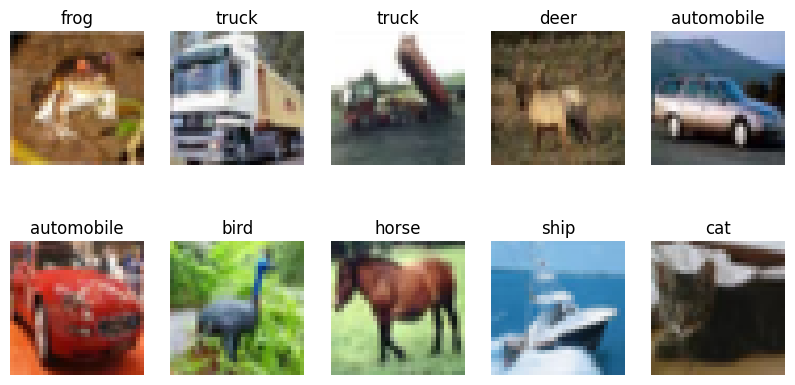

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 31ms/step - accuracy: 0.4372 - loss: 1.5393 - val_accuracy: 0.5378 - val_loss: 1.2983
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 27ms/step - accuracy: 0.5791 - loss: 1.1838 - val_accuracy: 0.5811 - val_loss: 1.1763
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.6363 - loss: 1.0306 - val_accuracy: 0.6214 - val_loss: 1.0890
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 26ms/step - accuracy: 0.6740 - loss: 0.9324 - val_accuracy: 0.6538 - val_loss: 1.0048
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.6980 - loss: 0.8602 - val_accuracy: 0.6761 - val_loss: 0.9330
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 27ms/step - accuracy: 0.7208 - loss: 0.8010 - val_accuracy: 0.6806 - val_loss: 0.9311
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.7349 - loss: 0.7528 - val_accuracy: 0.6938 - val_loss: 0.8909
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7468 -

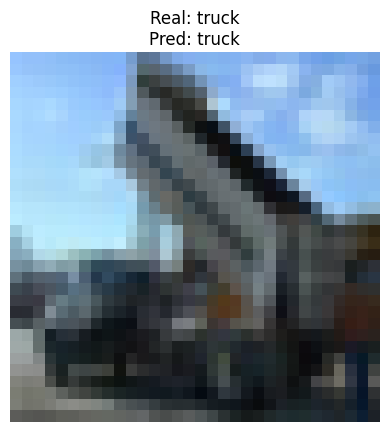

Đã lưu model


In [ ]:
# ==============================
# CNN CIFAR10 - Google Colab
# ==============================

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Chuẩn hóa dữ liệu
x_train = x_train / 255.0
x_test = x_test / 255.0

# Tên nhãn
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

# 2. Hiển thị một số ảnh
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.show()

# 3. Xây dựng CNN
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        64,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

# 4. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test,y_test)
)

# 6. Evaluate
loss, accuracy = model.evaluate(x_test,y_test)

print("Test Accuracy =", accuracy)

# 7. Dự đoán ảnh
index = 50

img = np.expand_dims(x_test[index], axis=0)

prediction = model.predict(img)

predicted_label = np.argmax(prediction)

print("Thực tế:", class_names[y_test[index][0]])
print("Dự đoán:", class_names[predicted_label])

plt.imshow(x_test[index])
plt.title(
    f"Real: {class_names[y_test[index][0]]}\nPred: {class_names[predicted_label]}"
)
plt.axis("off")
plt.show()

# 8. Lưu model
model.save("CNN_CIFAR10.h5")
print("Đã lưu model")

1. Fashion-MNIST
2. Gender (Male/Female)
Chọn bài (1 hoặc 2): 1
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.8387 - loss: 0.4460 - val_accuracy: 0.8744 - val_loss: 0.3511
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.8899 - loss: 0.3009 - val_accuracy: 0.8838 - val_loss: 0.3240
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9068 - loss: 0.2538 - val_accuracy: 0.9004 - val_loss: 0.2760
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9179 - loss: 0.2224 - val_accuracy: 0.9039 - val_loss: 0.2609
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9266 - loss: 0.1968 - val_accuracy: 0.9020 - val_loss: 0.2697
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9355 - loss: 0.173

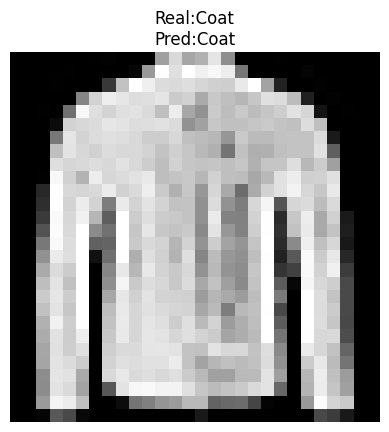

Đã lưu CNN_FASHION.h5


In [ ]:
# ==========================================
# CNN - BÀI 3 & 4 TRÊN GOOGLE COLAB
# ==========================================

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

print("1. Fashion-MNIST")
print("2. Gender (Male/Female)")

choice = input("Chọn bài (1 hoặc 2): ")

# ===================================================
# BÀI 3 - FASHION MNIST
# ===================================================
if choice == "1":

    class_names = [
        "T-shirt/top",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Ankle boot"
    ]

    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

    x_train = x_train.reshape(-1,28,28,1)/255.0
    x_test = x_test.reshape(-1,28,28,1)/255.0

    model = models.Sequential([
        layers.Conv2D(
            32,
            (3,3),
            activation='relu',
            input_shape=(28,28,1)
        ),

        layers.MaxPooling2D((2,2)),

        layers.Conv2D(
            64,
            (3,3),
            activation='relu'
        ),

        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(
            128,
            activation='relu'
        ),

        layers.Dense(
            10,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        x_train,
        y_train,
        epochs=10,
        validation_data=(x_test,y_test)
    )

    loss, acc = model.evaluate(x_test,y_test)

    print("Accuracy =", acc)

    index = 50

    img = np.expand_dims(x_test[index], axis=0)

    pred = model.predict(img)

    label = np.argmax(pred)

    print("Thực tế:", class_names[y_test[index]])
    print("Dự đoán:", class_names[label])

    plt.imshow(
        x_test[index].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Real:{class_names[y_test[index]]}\nPred:{class_names[label]}"
    )

    plt.axis("off")
    plt.show()

    model.save("CNN_FASHION.h5")

    print("Đã lưu CNN_FASHION.h5")


# ===================================================
# BÀI 4 - NHẬN DẠNG NAM NỮ
# ===================================================
elif choice == "2":

    from google.colab import files

    print("Upload dataset zip")

    uploaded = files.upload()

    # Dataset phải có dạng:
    #
    # gender_dataset
    #   train
    #      male
    #      female
    #   test
    #      male
    #      female

    !unzip -q *.zip

    train_dir = "gender_dataset/train"
    test_dir = "gender_dataset/test"

    train_data = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        image_size=(128,128),
        batch_size=32
    )

    test_data = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        image_size=(128,128),
        batch_size=32
    )

    model = models.Sequential([

        layers.Rescaling(
            1./255,
            input_shape=(128,128,3)
        ),

        layers.Conv2D(
            32,
            (3,3),
            activation='relu'
        ),

        layers.MaxPooling2D(),

        layers.Conv2D(
            64,
            (3,3),
            activation='relu'
        ),

        layers.MaxPooling2D(),

        layers.Conv2D(
            128,
            (3,3),
            activation='relu'
        ),

        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(
            128,
            activation='relu'
        ),

        layers.Dropout(0.5),

        layers.Dense(
            1,
            activation='sigmoid'
        )
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_data,
        epochs=10,
        validation_data=test_data
    )

    loss, acc = model.evaluate(test_data)

    print("Accuracy =", acc)

    model.save("CNN_GENDER.h5")

    print("Đã lưu CNN_GENDER.h5")

else:
    print("Chọn sai!")

# Mục mới